In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
preexisting_df = pd.read_csv("/scratch1/smaruj/suppressing_CTCFs/results_repeated/preexisting_ctcf_df_with_SCD.tsv", sep="\t")
new_df = pd.read_csv("/scratch1/smaruj/suppressing_CTCFs/results_repeated/new_ctcf_df_with_SCD.tsv", sep="\t")

comparing with old insertion scores of all mouse CTCFs

In [3]:
import h5py

In [4]:
h5_path = "/project2/fudenber_735/smaruj/akitaX1_analyses_data/virtual_insertion_singletons/model_0.h5"

In [5]:
with h5py.File(h5_path, "r") as f:
    scd = f["SCD_h1_m0"][:]            # (75600, 6)
    background_index = f["background_index"][:]  # (75600,)
    seq_id = f["seq_id"][:]            # (75600,)

# Take 0th target
scd_target0 = scd[:, 0]  # shape (75600,)

# Average over backgrounds
# Assuming background_index goes from 0..9 for the 10 backgrounds
df = pd.DataFrame({
    "seq_id": seq_id,
    "background_index": background_index,
    "SCD": scd_target0
})

# Average SCD per seq_id over backgrounds
df_avg = df.groupby("seq_id")["SCD"].mean().reset_index()
df_avg["type"] = "mouse ctcfs"

In [6]:
df_avg

,seq_id,SCD,type
0,0,1.914600,mouse ctcfs
1,1,45.871876,mouse ctcfs
2,2,0.122681,mouse ctcfs
3,3,0.148798,mouse ctcfs
4,4,0.346716,mouse ctcfs
...,...,...,...
7555,7555,0.299622,mouse ctcfs
7556,7556,0.814233,mouse ctcfs
7557,7557,24.220312,mouse ctcfs
7558,7558,0.202350,mouse ctcfs


In [7]:
# Compute SCD_avg for preexisting and new data
scd_cols_preexisting = [c for c in preexisting_df.columns if c.startswith("SCD_bg")]
preexisting_df["SCD_avg"] = preexisting_df[scd_cols_preexisting].mean(axis=1)
preexisting_df["type"] = "Preexisting"

scd_cols_new = [c for c in new_df.columns if c.startswith("SCD_bg")]
new_df["SCD_avg"] = new_df[scd_cols_new].mean(axis=1)
new_df["type"] = "New"

In [8]:
# Combine previous data
all_avg = pd.concat([preexisting_df[["SCD_avg","type"]], new_df[["SCD_avg","type"]]], ignore_index=True)

In [9]:
# Add H5 data
# df_avg is from previous step: averaged SCD_h1_m0 per seq_id
df_avg_h5 = df_avg.rename(columns={"SCD": "SCD_avg"}).copy()
all_avg_h5 = pd.concat([all_avg, df_avg_h5[["SCD_avg","type"]]], ignore_index=True)

/tmp/SLURM_2511835/ipykernel_3170410/2149439310.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


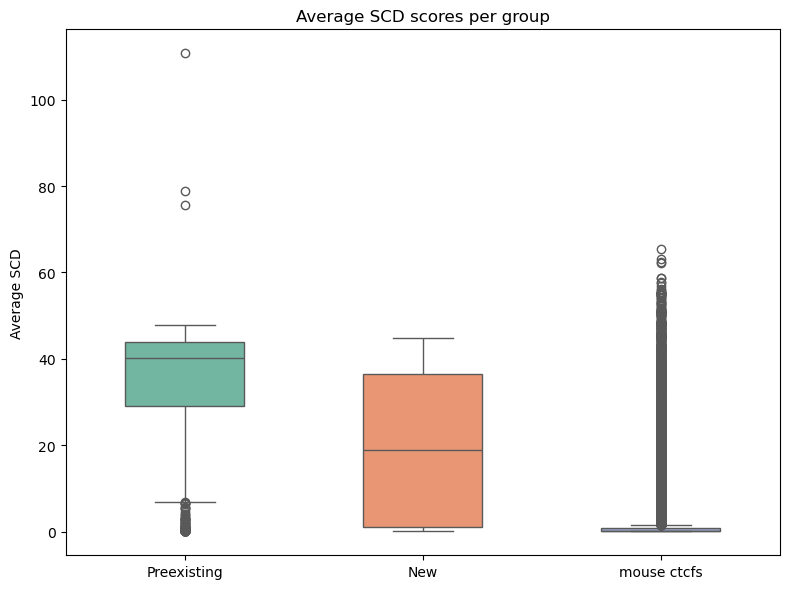

In [12]:
# ---------------------------
# Boxplot
# ---------------------------
plt.figure(figsize=(8,6))
sns.boxplot(
    data=all_avg_h5,
    x="type",
    y="SCD_avg",
    palette="Set2",
    width=0.5
)
plt.title("Average SCD scores per group")
plt.ylabel("Average SCD")
plt.xlabel("")
plt.tight_layout()
plt.show()

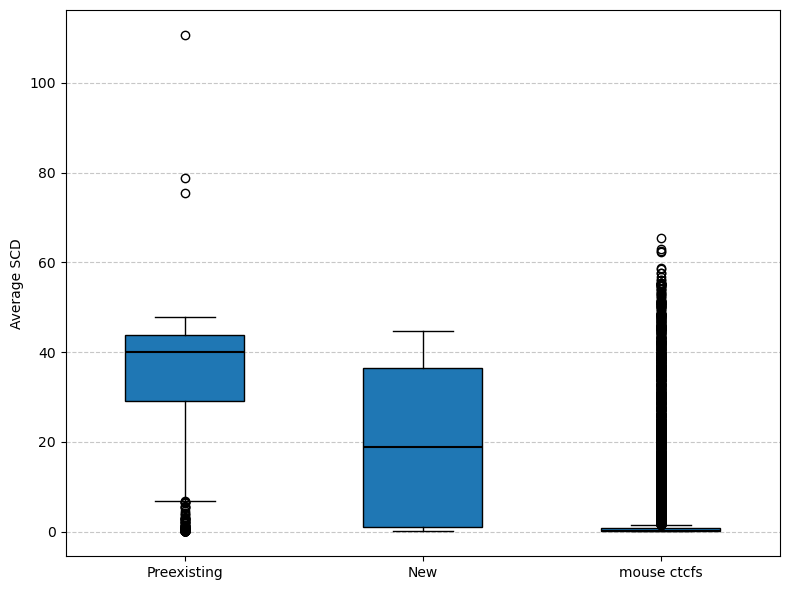

In [16]:
# Prepare data in the correct order
groups = all_avg_h5["type"].unique()
data = [
    all_avg_h5.loc[all_avg_h5["type"] == g, "SCD_avg"].values
    for g in groups
]

plt.figure(figsize=(8, 6))

plt.boxplot(
    data,
    widths=0.5,
    patch_artist=True,   # needed to fill boxes
    boxprops=dict(facecolor="tab:blue", edgecolor="black"),
    medianprops=dict(color="black", linewidth=1.5),
    whiskerprops=dict(color="black"),
    capprops=dict(color="black"),
    # flierprops=dict(marker="o", markerfacecolor="tab:blue", alpha=0.5)
)
plt.grid(axis="y", linestyle="--", alpha=0.7)

plt.xticks(range(1, len(groups) + 1), groups)
# plt.title("Average SCD scores per group")
plt.ylabel("Average SCD")
plt.xlabel("")

plt.tight_layout()
plt.savefig("average_insertion_score.svg", format="svg")

plt.show()


In [ ]:
# ---------------------------
# Histogram
# ---------------------------
plt.figure(figsize=(8,6))
sns.histplot(data=all_avg_h5, x="SCD_avg", hue="type", bins=50, kde=True, palette="Set2", alpha=0.5)
plt.title("Distribution of SCD scores")
plt.xlabel("Average SCD")
plt.ylabel("Count")
plt.tight_layout()
plt.show()